### There are several ways to establish connection to local postgresql db but we will use pandas and sqlalchemy libraries

### To install it RUN THE NEXT CELL BY CLICKING ON IT AND SHIFT+ENTER or click RUN BUTTON ABOVE

In [2]:
!pip install pandas sqlalchemy

In [5]:
!pip install psycopg2-binary


   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ------------ --------------------------- 0.8/2.6 MB 2.7 MB/s eta 0:00:01
   -------------------- ------------------- 1.3/2.6 MB 2.6 MB/s eta 0:00:01
   -------------------------------- ------- 2.1/2.6 MB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 3.0 MB/s eta 0:00:00


### As now we have proper libraries we can import and use them 

### Execute the following cell 

In [3]:
import pandas as pd
from sqlalchemy import create_engine

def connect_to_db(dbname: str, user: str, password: str, host: str = "localhost", port: str = "5432"):
    try:
        conn_str = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"
        engine = create_engine(conn_str)
        print(f"Engine created for database: {dbname}")
        return engine
    except Exception as e:
        print(f"Error creating engine for {dbname}: {e}")
        return None


### in previous cell we creted connect_to_db function which we can reuse to connect to both of our DBs, we just need to provide propper attributers. 

### In the next cell you can find example of establishing connection to SRC DB and reading data from s1.s1_channels into separate pandas dataframe

### Execute the following cell 

In [6]:
src_engine = connect_to_db(
    dbname="dwh_src_hw_db",
    user="postgres",
    password="postgres"
)

s1_channels_df = pd.read_sql("SELECT * FROM s1.s1_channels", src_engine)
s1_channels_df

Engine created for database: dwh_src_hw_db


,channel_id,channel_name,channel_location
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
153,154,YAOBAO.COM,Internet
154,155,CATALOG.ONLINER.BY,Internet
155,156,5ELEMENT.BY,Internet
156,157,ALLEGRO.PL,Internet


 ## YOUR TASK IS TO ESTABLISH SEPARATE 

 trg_engine 

 ## and conect to dwh_hw_db in the next cell

In [9]:
trg_engine = connect_to_db(
    dbname="dwh_hw_db",
    user="postgres",
    password="postgres"
)

lnd_s1_channels_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_channels", trg_engine)
lnd_s1_channels_df

Engine created for database: dwh_hw_db


,channel_id,channel_name,channellocation
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
151,152,EBAY.COM,N/A - Internet
152,153,ALIEXPRESS.COM,N/A - Internet
153,154,YAOBAO.COM,N/A - Internet
154,155,CATALOG-ONLINER.BY,N/A - Internet


#### AS we have 2 DFs with data from 2 tables we need to compare them. To do so we can create separate DF s1_channels_comparison_df

### Execute the following cell 

In [10]:
s1_channels_comparison_df = s1_channels_df.merge(
    lnd_s1_channels_df,
    on='channel_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True  
)
s1_channels_comparison_df

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge
0,1,STORE - 1,621 Hovde Circle,STORE - 1,621 Hovde Circle,both
1,10,STORE - 10,6840 Pennsylvania Terrace,STORE - 10,6840 Pennsylvania Terrace,both
2,100,STORE - 100,72760 Helena Avenue,STORE - 100,72760 Helena Avenue,both
3,101,STORE - 101,40 Lyons Place,STORE - 101,40 Lyons Place,both
4,102,STORE - 102,04 Ludington Pass,STORE - 102,04 Ludington Pass,both
...,...,...,...,...,...,...
153,95,STORE - 95,6354 Lukken Circle,STORE - 95,6354 Lukken Circle,both
154,96,STORE - 96,1 Lighthouse Bay Way,STORE - 96,1 Lighthouse Bay Way,both
155,97,STORE - 97,03 Moland Parkway,STORE - 97,03 Moland Parkway,both
156,98,STORE - 98,24450 Kim Center,STORE - 98,24450 Kim Center,both


### Since we use indicator=True in the merge, pandas automatically provides the _merge column with values left_only, right_only, or both for the ID values.

### However, we want to make the statuses more meaningful, similar to what we did in SQL and also check for differences in other attributes, not just IDs.
### For this reason, I have prepared a separate function specifically for computing reconciliation_status for the channels table.

### Execute the following cell 

In [12]:
def get_s1_channels_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['channel_name_src'] != row['channel_name_lnd']:
        mismatches.append('channel_name')
    if row['channel_location'] != row['channellocation']:
        mismatches.append('channel_location')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

### Since this function expects a single row as input, we can apply it to our s1_channel_comparison_df and create a new column to store the adapted reconciliation statuses.

### Execute the following cell 


In [13]:
s1_channels_comparison_df['reconciliation_status'] = s1_channels_comparison_df.apply(get_s1_channels_reconciliation_status, axis=1)

### And now, let’s keep only the rows with discrepancies (i.e., excluding rows where everything matches).

In [ ]:
s1_channels_issues_df = s1_channels_comparison_df[s1_channels_comparison_df['reconciliation_status'] != 'Match']
display(s1_channels_issues_df.head(20))

# Task: Reconcile all other table pairs from SRC and LND, similar to what we did for the channels table.

## Instructions:

### Tables to compare:

###### s1.s1_products → lnd.lnd_s1_products
###### s1.s1_sales → lnd.lnd_s1_sales
###### s2.s2_channels → lnd.lnd_s2_channels
###### s2.s2_client_sales → lnd.lnd_s2_client_sales
###### s2.s2_clients → lnd.lnd_s2_clients
###### s2.s2_locations → lnd.lnd_s2_locations

## For each table pair:

### 1. Load the SRC and LND tables into pandas DataFrames.
### 2. Perform a full outer merge on the primary key column(s).
### 3. Apply a function like get_reconciliation_status(row) to classify each row into statuses:
###### 'Only in source'
###### 'Only in landing'
###### 'Mismatch in <column_name>'
###### 'Match'

### Keep only rows with issues (statuses != 'Match').

## 4. Create a consolidated result DataFrame with the following columns:

###### table_name	Name of the table being compared
###### key_column	Primary key column used for reconciliation
###### src_id	ID value from source table
###### trg_id	ID value from landing table
###### reconciliation_status	Status of the row (Only in source, Only in landing, etc.)

## 5. Populate the final result DataFrame with all discrepancies from all table comparisons.

### Tips / Methods:

### Use pd.merge(..., how='outer', indicator=True) to combine SRC and LND tables.
### Apply your reconciliation status function row-wise with df.apply(..., axis=1).
### Filter only rows with issues using df[df['reconciliation_status'] != 'Match'].
### Concatenate multiple issues_df DataFrames using pd.concat([...], ignore_index=True) to create the final consolidated DataFrame.

In [20]:
#YOUR CODE HERE AND BELOW

In [21]:

s1_clients_df = pd.read_sql("SELECT * FROM s1.s1_clients", src_engine)
s1_clients_df

,client_id,first_name,middle_name,last_name,email,phone,first_purchase
0,484,Rickie,Hobie,Duckerin,hduckerindf@rambler.ru,+204994284442,22-JAN-00
1,485,Darrel,Jordanna,Lydford,jlydforddg@epa.gov,+77446764556,28-AUG-00
2,486,Sybilla,Gabriello,Stanhope,gstanhopedh@mit.edu,+2348872129631,01-JAN-00
3,487,Lukas,Shanta,MacGall,smacgalldi@hud.gov,+73982865774,01-SEP-00
4,488,Pepita,Kore,Cristofor,kcristofordj@trellian.com,+817722829895,19-OCT-00
...,...,...,...,...,...,...,...
695,696,Bron,Burnard,Conochie,bconochiejb@nih.gov,+634102487274,18-JUL-00
696,697,Jeanie,Titos,Sloat,tsloatjc@boston.com,+627781296427,01-JUN-00
697,698,Berte,Nathalie,Klos,nklosjd@foxnews.com,+631702650427,07-DEC-00
698,699,Christean,Alyce,Yegorkin,ayegorkinje@opera.com,+5987059266523,24-SEP-00


In [22]:
lnd_s1_clients_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_clients", trg_engine)
lnd_s1_clients_df

,client_id,first_name,middle_name,last_name,email,phone,first_purchase
0,484,Rickie,Hobie,Duckerin,hduckerindf@rambler.ru,+204994284442,22-JAN-00
1,485,Darrel,Jordanna,Lydford,jlydforddg@epa.gov,+77446764556,28-AUG-00
2,486,Sybilla,Gabriello,Stanhope,gstanhopedh@mit.edu,+2348872129631,01-JAN-00
3,487,Lukas,Shanta,MacGall,smacgalldi@hud.gov,+73982865774,01-SEP-00
4,488,Pepita,Kore,Cristofor,kcristofordj@trellian.com,+817722829895,19-OCT-00
...,...,...,...,...,...,...,...
706,696,Bron,Burnard,Conochie,bconochiejb@nih.gov,+634102487274,18-JUL-00
707,697,Jeanie,Titos,Sloat,tsloatjc@boston.com,+627781296427,01-JUN-00
708,698,Berte,Nathalie,Klos,nklosjd@foxnews.com,+631702650427,07-DEC-00
709,699,Christean,Alyce,Peterson,ayegorkinje@opera.com,+5987059266523,24-SEP-00


In [23]:
s1_clients_comparison_df = s1_clients_df.merge(
    lnd_s1_clients_df,
    on='client_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True  
)
s1_clients_comparison_df

,client_id,first_name_src,middle_name_src,last_name_src,email_src,phone_src,first_purchase_src,first_name_lnd,middle_name_lnd,last_name_lnd,email_lnd,phone_lnd,first_purchase_lnd,_merge
0,1,Goldarina,Dory,Dadswell,ddadswell0@cyberchimps.com,+2341036774750,23-FEB-00,Goldarina,Dory,Dadswell,ddadswell0@cyberchimps.com,+2341036774750,23-FEB-00,both
1,10,Averyl,Arni,Emmer,aemmer9@yandex.ru,+3891475102221,15-JAN-00,Averyl,Arni,Emmer,aemmer9@yandex.ru,+3891475102221,15-JAN-00,both
2,100,Cynthy,Ricardo,Ducroe,rducroe2r@princeton.edu,+668603957579,10-JUL-00,Cynthy,Ricardo,Ducroe,rducroe2r@princeton.edu,+668603957579,10-JUL-00,both
3,101,Rodina,Salem,Ousbie,sousbie2s@creativecommons.org,+869985208554,27-JAN-00,Rodina,Salem,Ousbie,sousbie2s@creativecommons.org,+869985208554,27-JAN-00,both
4,102,Ansel,Agathe,Stratley,astratley2t@addtoany.com,+517483211721,11-AUG-00,Ansel,Agathe,Stratley,astratley2t@addtoany.com,+517483211721,11-AUG-00,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
706,95,Glynis,Vick,Trynor,vtrynor2m@indiegogo.com,+861511337096,03-AUG-00,Glynis,Vick,Trynor,vtrynor2m@indiegogo.com,+861511337096,03-AUG-00,both
707,96,Crystal,Louisa,Folini,lfolini2n@google.com.au,+18646508486,28-APR-00,Crystal,Louisa,Folini,lfolini2n@google.com.au,+18646508486,28-APR-00,both
708,97,Saundra,Joelle,Fullerton,jfullerton2o@blogs.com,+465369756675,28-APR-00,Saundra,Joelle,Fullerton,jfullerton2o@blogs.com,+465369756675,28-APR-00,both
709,98,Mycah,Joanie,Wynn,jwynn2p@github.com,+72328137238,29-MAY-00,Mycah,Joanie,Wynn,jwynn2p@github.com,+72328137238,29-MAY-00,both


In [24]:
def get_s1_clients_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['first_name_src'] != row['first_name_lnd']:
        mismatches.append('channel_name')
    if row['middle_name_src'] != row['middle_name_lnd']:
        mismatches.append('middle_name')
    if row['last_name_src'] != row['last_name_lnd']:
        mismatches.append('last_name')
    if row['email_src'] != row['email_lnd']:
        mismatches.append('email')
    if row['phone_src'] != row['phone_lnd']:
        mismatches.append('phone')
    if row['first_purchase_src'] != row['first_purchase_lnd']:
        mismatches.append('first_purchase')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

In [25]:
s1_clients_comparison_df['reconciliation_status'] = s1_clients_comparison_df.apply(get_s1_clients_reconciliation_status, axis=1)

In [26]:
s1_clients_issues_df = s1_clients_comparison_df[s1_clients_comparison_df['reconciliation_status'] != 'Match']
display(s1_clients_issues_df.head(20))

,client_id,first_name_src,middle_name_src,last_name_src,email_src,phone_src,first_purchase_src,first_name_lnd,middle_name_lnd,last_name_lnd,email_lnd,phone_lnd,first_purchase_lnd,_merge,reconciliation_status
676,699,Christean,Alyce,Yegorkin,ayegorkinje@opera.com,+5987059266523,24-SEP-00,Christean,Alyce,Peterson,ayegorkinje@opera.com,+5987059266523,24-SEP-00,both,Mismatch in last_name
679,700,Gilemette,Amii,Cantrell,acantrelljf@rakuten.co.jp,+2349166424398,23-SEP-00,Gilemette,Amii,Cantrell,acantrelljf@rakuten.co.jp,+2345678903,23-SEP-00,both,Mismatch in phone


In [25]:
s1_clients_comparison_df['reconciliation_status'] = s1_clients_comparison_df.apply(get_s1_clients_reconciliation_status, axis=1)

In [26]:
s1_clients_issues_df = s1_clients_comparison_df[s1_clients_comparison_df['reconciliation_status'] != 'Match']
display(s1_clients_issues_df.head(20))

,client_id,first_name_src,middle_name_src,last_name_src,email_src,phone_src,first_purchase_src,first_name_lnd,middle_name_lnd,last_name_lnd,email_lnd,phone_lnd,first_purchase_lnd,_merge,reconciliation_status
676,699,Christean,Alyce,Yegorkin,ayegorkinje@opera.com,+5987059266523,24-SEP-00,Christean,Alyce,Peterson,ayegorkinje@opera.com,+5987059266523,24-SEP-00,both,Mismatch in last_name
679,700,Gilemette,Amii,Cantrell,acantrelljf@rakuten.co.jp,+2349166424398,23-SEP-00,Gilemette,Amii,Cantrell,acantrelljf@rakuten.co.jp,+2345678903,23-SEP-00,both,Mismatch in phone


In [27]:

s1_products_df = pd.read_sql("SELECT * FROM s1.s1_products", src_engine)
s1_products_df

,product_id,cost,product_name
0,1,6.33,mirror
1,2,3.01,drill press
2,3,7.55,screw
3,4,6.69,soap
4,5,3.59,doll
5,6,1.37,bottle
6,7,6.08,door
7,8,3.31,needle
8,9,7.02,mp3 player
9,10,2.4,bananas


In [28]:
lnd_s1_products_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_products", trg_engine)
lnd_s1_products_df

,product_id,cost,product_name
0,1,6.33,mirror
1,2,3.01,drill press
2,3,7.55,screw
3,4,6.69,soap
4,5,3.59,doll
5,6,1.37,bottle
6,7,6.08,door
7,8,3.31,needle
8,9,7.02,mp3 player
9,10,2.4,bananas


In [30]:
s1_products_comparison_df = s1_products_df.merge(
    lnd_s1_products_df,
    on='product_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True  
)
s1_products_comparison_df

,product_id,cost_src,product_name_src,cost_lnd,product_name_lnd,_merge
0,1,6.33,mirror,6.33,mirror,both
1,10,2.4,bananas,2.4,bananas,both
2,11,3.19,thermostat,3.19,thermostat,both
3,12,1.71,zipper,1.71,zipper,both
4,13,5.64,desk,5.64,desk,both
5,14,6.91,floor,6.91,floor,both
6,15,9.4,playing card,9.4,playing card,both
7,16,3.16,boom box,3.16,boom box,both
8,17,6.47,leg warmers,6.47,leg warmers,both
9,18,2.64,coasters,2.64,coasters,both


In [31]:
def get_s1_products_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['cost_src'] != row['cost_lnd']:
        mismatches.append('cost')
    if row['product_name_src'] != row['product_name_lnd']:
        mismatches.append('product_name')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

In [32]:
s1_products_comparison_df['reconciliation_status'] = s1_products_comparison_df.apply(get_s1_products_reconciliation_status, axis=1)

In [33]:
s1_products_issues_df = s1_products_comparison_df[s1_products_comparison_df['reconciliation_status'] != 'Match']
display(s1_products_issues_df.head(20))

,product_id,cost_src,product_name_src,cost_lnd,product_name_lnd,_merge,reconciliation_status
45,50,NaN,NaN,9.06,helmet,right_only,Only in landing


In [35]:
s1_sales_df = pd.read_sql("SELECT * FROM s1.s1_sales", src_engine)
s1_sales_df

,client_id,channel_id,sale_date,units,product_id,purchase_date
0,11,44,01-APR-06,2,28,07-APR-06
1,400,71,30-JUN-05,9,17,09-JUL-05
2,188,14,17-JUL-06,5,43,25-JUL-06
3,435,127,21-DEC-06,6,29,24-DEC-06
4,86,23,07-OCT-06,11,33,08-OCT-06
...,...,...,...,...,...,...
22395,673,45,26-SEP-05,7,16,05-OCT-05
22396,339,28,07-JAN-06,2,48,15-JAN-06
22397,112,30,03-OCT-05,8,24,05-OCT-05
22398,511,63,21-AUG-05,3,11,30-AUG-05


In [36]:
lnd_s1_sales_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_sales", trg_engine)
lnd_s1_sales_df

,client_id,channel_id,sale_date,units,product_id,purchase_date
0,11,44,01-APR-06,2,28,07-APR-06
1,400,71,30-JUN-05,9,17,09-JUL-05
2,188,14,17-JUL-06,5,43,25-JUL-06
3,435,127,21-DEC-06,6,29,24-DEC-06
4,86,23,07-OCT-06,11,33,08-OCT-06
...,...,...,...,...,...,...
22219,673,45,26-SEP-05,7,16,05-OCT-05
22220,339,28,07-JAN-06,2,48,15-JAN-06
22221,112,30,03-OCT-05,8,24,05-OCT-05
22222,511,63,21-AUG-05,3,11,30-AUG-05


In [38]:
s1_sales_comparison_df = s1_sales_df.merge(
    lnd_s1_sales_df,
    on=['client_id', 'channel_id', 'product_id', 'sale_date'],
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True  
)
s1_sales_comparison_df

,client_id,channel_id,sale_date,units_src,product_id,purchase_date_src,units_lnd,purchase_date_lnd,_merge
0,1,11,21-MAY-06,6,32,24-MAY-06,6,24-MAY-06,both
1,1,111,02-OCT-06,15,37,08-OCT-06,15,08-OCT-06,both
2,1,13,09-FEB-05,9,49,11-FEB-05,9,11-FEB-05,both
3,1,135,26-DEC-06,4,22,29-DEC-06,4,29-DEC-06,both
4,1,21,16-APR-05,6,40,25-APR-05,6,25-APR-05,both
...,...,...,...,...,...,...,...,...,...
22395,99,80,03-APR-06,12,47,07-APR-06,12,07-APR-06,both
22396,99,81,22-SEP-06,9,43,26-SEP-06,9,26-SEP-06,both
22397,99,88,12-NOV-06,3,6,19-NOV-06,3,19-NOV-06,both
22398,99,90,09-MAY-05,6,41,11-MAY-05,6,11-MAY-05,both


In [41]:
def get_s1_sales_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['units_src'] != row['units_lnd']:
        mismatches.append('units')
    if row['purchase_date_src'] != row['purchase_date_lnd']:
        mismatches.append('purchase_date')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

In [42]:
s1_sales_comparison_df['reconciliation_status'] = s1_sales_comparison_df.apply(get_s1_sales_reconciliation_status, axis=1)

In [43]:
s1_sales_issues_df = s1_sales_comparison_df[s1_sales_comparison_df['reconciliation_status'] != 'Match']
display(s1_sales_issues_df.head(20))

,client_id,channel_id,sale_date,units_src,product_id,purchase_date_src,units_lnd,purchase_date_lnd,_merge,reconciliation_status
180,104,123,03-MAY-06,14,35,09-MAY-06,NaN,NaN,left_only,Only in source
339,108,36,20-OCT-05,1,23,21-OCT-05,NaN,NaN,left_only,Only in source
417,110,110,17-APR-05,4,8,25-APR-05,NaN,NaN,left_only,Only in source
508,112,84,19-JAN-06,11,10,21-JAN-06,NaN,NaN,left_only,Only in source
509,112,86,18-NOV-06,11,32,23-NOV-06,NaN,NaN,left_only,Only in source
562,114,24,23-SEP-05,4,16,30-SEP-05,NaN,NaN,left_only,Only in source
677,118,130,05-APR-05,2,36,06-APR-05,NaN,NaN,left_only,Only in source
792,121,125,26-APR-05,8,27,02-MAY-05,NaN,NaN,left_only,Only in source
881,123,98,26-MAR-05,7,50,03-APR-05,NaN,NaN,left_only,Only in source
946,125,83,18-AUG-05,7,31,25-AUG-05,NaN,NaN,left_only,Only in source


In [44]:
s2_channels_df = pd.read_sql("SELECT * FROM s2.s2_channels", src_engine)
s2_channels_df
s2_clients_df = pd.read_sql("SELECT * FROM s2.s2_clients", src_engine)
s2_clients_df
s2_locations_df = pd.read_sql("SELECT * FROM s2.s2_locations", src_engine)
s2_locations_df
s2_client_sales_df = pd.read_sql("SELECT * FROM s2.s2_client_sales", src_engine)
s2_client_sales_df

,client_id,channel_id,saled_at,product_id,product_name,product_price,product_amount,sold_date
0,cl7,ch17,12-JUL-11,pr102,Catwalk Boots,156.1208571,2,13-JUL-11
1,cl61,ch7,03-MAY-11,pr103,Magnum Footwear Lifestyle,157.9545714,7,04-MAY-11
2,cl11,ch25,13-OCT-11,pr105,Rialto Boots,161.622,7,14-OCT-11
3,cl68,ch34,07-JUL-12,pr107,"Alfajr WY16B Youth Digital Watch - For Men, Boys",165.2894286,7,08-JUL-12
4,cl65,ch8,01-NOV-11,pr108,La Briza Ashley Boots,167.1231429,3,02-NOV-11
...,...,...,...,...,...,...,...,...
1291,cl65,ch28,08-FEB-10,pr2,FabHomeDecor Fabric Double Sofa Bed,13.13,5,09-FEB-10
1292,cl20,ch6,23-SEP-10,pr78,SANTOSH ROYAL FASHION Cotton Printed King size...,112.1117143,7,24-SEP-10
1293,cl52,ch8,21-JAN-12,pr151,Casela CAS-W-13 Basic Analog Watch - For Boys...,245.9728571,5,22-JAN-12
1294,cl13,ch3,03-JAN-10,pr177,Rich Club Apple Shaped LED Digital Watch - Fo...,293.6494286,2,04-JAN-10


In [47]:
lnd_s2_channels_df = pd.read_sql("SELECT * FROM lnd.lnd_s2_channels", trg_engine)
lnd_s2_channels_df
lnd_s2_clients_df = pd.read_sql("SELECT * FROM lnd.lnd_s2_clients", trg_engine)
lnd_s2_clients_df
lnd_s2_locations_df = pd.read_sql("SELECT * FROM lnd.lnd_s2_locations", trg_engine)
lnd_s2_locations_df
lnd_s2_client_sales_df = pd.read_sql("SELECT * FROM lnd.lnd_s2_client_sales", trg_engine)
lnd_s2_client_sales_df

,client_id,channel_id,saled_at,product_id,product_name,product_price,product_amount,sold_date
0,cl7,ch17,12-JUL-11,pr102,Catwalk Boots,156.1208571,2,13-JUL-11
1,cl61,ch7,03-MAY-11,pr103,Magnum Footwear Lifestyle,157.9545714,7,04-MAY-11
2,cl11,ch25,13-OCT-11,pr105,Rialto Boots,161.622,7,14-OCT-11
3,cl68,ch34,07-JUL-12,pr107,"Alfajr WY16B Youth Digital Watch - For Men, Boys",165.2894286,7,08-JUL-12
4,cl65,ch8,01-NOV-11,pr108,La Briza Ashley Boots,167.1231429,3,02-NOV-11
...,...,...,...,...,...,...,...,...
1286,cl65,ch28,08-FEB-10,pr2,FabHomeDecor Fabric Double Sofa Bed,13.13,5,09-FEB-10
1287,cl20,ch6,23-SEP-10,pr78,SANTOSH ROYAL FASHION Cotton Printed King size...,112.1117143,7,24-SEP-10
1288,cl52,ch8,21-JAN-12,pr151,Casela CAS-W-13 Basic Analog Watch - For Boys...,245.9728571,5,22-JAN-12
1289,cl13,ch3,03-JAN-10,pr177,Rich Club Apple Shaped LED Digital Watch - Fo...,293.6494286,2,04-JAN-10


In [48]:
s2_channels_comparison_df = s2_channels_df.merge(
    lnd_s2_channels_df,
    on=['channel_id'],
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)
s2_channels_comparison_df


,channel_id,channel_name_src,location_id_src,channel_name_lnd,location_id_lnd,_merge
0,ch1,Cold sales (phone),1,Cold sales (phone),1,both
1,ch10,In-mall store 4,3,In-mall store 4,3,both
2,ch11,Separate store 1,4,Separate store 1,4,both
3,ch12,Separate store 2,5,Separate store 2,5,both
4,ch13,Separate store 3,6,Separate store 3,6,both
5,ch14,Separate store 4,7,Separate store 4,7,both
6,ch15,Separate store 5,8,Separate store 5,8,both
7,ch16,Separate store 6,9,Separate store 6,9,both
8,ch17,Separate store 7,10,Separate store 7,10,both
9,ch18,Separate store 8,11,Separate store 8,11,both


In [49]:
s2_clients_comparison_df = s2_clients_df.merge(
    lnd_s2_clients_df,
    on=['client_id', 'valid_from'],
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)
s2_clients_comparison_df


,client_id,first_name_src,last_name_src,email_src,phone_code_src,phone_number_src,first_purchase_src,valid_from,valid_to_src,first_name_lnd,last_name_lnd,email_lnd,phone_code_lnd,phone_number_lnd,first_purchase_lnd,valid_to_lnd,_merge
0,cl1,Dionisio,Newlove,dnewlove0@privacy.gov.au,375,2175622666,17-Mar-01,17-Mar-01,12-Mar-21,Dionisio,Newlove,dnewlove0@privacy.gov.au,375,2175622666,17-Mar-01,12-Mar-21,both
1,cl10,Ravi,O'Hdirscoll,rohdirscoll9@engadget.com,7,3595936225,11-Sep-01,11-Sep-01,6-Sep-21,Ravi,O'Hdirscoll,rohdirscoll9@engadget.com,7,3595936225,11-Sep-01,6-Sep-21,both
2,cl11,Gardner,Mansfield,gmansfielda@noaa.gov,7,5207714975,9-Apr-01,9-Apr-01,4-Apr-21,Gardner,Mansfield,gmansfielda@noaa.gov,7,5207714975,9-Apr-01,4-Apr-21,both
3,cl12,Terrell,Thorington,tthoringtonb@cbsnews.com,7,6567007598,6-May-01,6-May-01,1-May-21,Terrell,Thorington,tthoringtonb@cbsnews.com,7,6567007598,6-May-01,1-May-21,both
4,cl13,Godfry,Muggleton,gmuggletonc@latimes.com,375,4415418622,23-Nov-01,23-Nov-01,18-Nov-21,Godfry,Muggleton,gmuggletonc@latimes.com,375,4415418622,23-Nov-01,18-Nov-21,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,cl78,Shellysheldon,Tinklin,stinklin25@reference.com,375,5692742928,16-Feb-02,16-Feb-02,11-Feb-22,Shellysheldon,Tinklin,stinklin25@reference.com,375,5692742928,16-Feb-02,11-Feb-22,both
76,cl79,Thaddus,Warboy,twarboy26@fastcompany.com,375,7488445465,15-Jan-01,15-Jan-01,10-Jan-21,Thaddus,Warboy,twarboy26@fastcompany.com,375,7488445465,15-Jan-01,10-Jan-21,both
77,cl8,Silvio,Blamey,sblamey7@surveymonkey.com,7,4929364232,13-Feb-02,13-Feb-02,8-Feb-22,Silvio,Blamey,sblamey7@surveymonkey.com,7,4929364232,13-Feb-02,8-Feb-22,both
78,cl80,Gannie,Biddiss,gbiddiss27@behance.net,375,7785342017,2-Aug-00,2-Aug-00,28-Jul-20,Gannie,Biddiss,gbiddiss27@behance.net,375,7785342017,2-Aug-00,28-Jul-20,both


In [50]:
s2_locations_comparison_df = s2_locations_df.merge(
    lnd_s2_locations_df,
    on=['location_id'],
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)
s2_locations_comparison_df


,location_id,location_name_src,location_name_lnd,_merge
0,1,N/A - Cold Sales,N/A - Cold Sales,both
1,10,Store at:891 Little Fleur Junction,Store at:891 Little Fleur Junction,both
2,11,Store at:4 Westerfield Drive,Store at:4 Westerfield Drive,both
3,12,Store at:6 Nevada Crossing,Store at:6 Nevada Crossing,both
4,13,Store at:488 Vernon Center,Store at:488 Vernon Center,both
5,14,Store at:627 Holmberg Alley,Store at:627 Holmberg Alley,both
6,15,Store at:00 Bay Court,Store at:00 Bay Court,both
7,16,Store at:59 Hayes Point,Store at:59 Hayes Point,both
8,17,Store at:91871 Emmet Way,Store at:91871 Emmet Way,both
9,18,Store at:695 Ruskin Terrace,Store at:695 Ruskin Terrace,both


In [51]:
s2_client_sales_comparison_df = s2_client_sales_df.merge(
    lnd_s2_client_sales_df,
    on=['client_id', 'channel_id', 'product_id', 'saled_at'],
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)
s2_client_sales_comparison_df


,client_id,channel_id,saled_at,product_id,product_name_src,product_price_src,product_amount_src,sold_date_src,product_name_lnd,product_price_lnd,product_amount_lnd,sold_date_lnd,_merge
0,cl1,ch12,18-MAY-12,pr107,"Alfajr WY16B Youth Digital Watch - For Men, Boys",165.2894286,4,19-MAY-12,"Alfajr WY16B Youth Digital Watch - For Men, Boys",165.2894286,4,19-MAY-12,both
1,cl1,ch15,12-SEP-10,pr121,Get Glamr Designer Uggy Boots,190.9614286,3,13-SEP-10,Get Glamr Designer Uggy Boots,190.9614286,3,13-SEP-10,both
2,cl1,ch25,28-AUG-12,pr211,Jacques Farel KWD2324 Analog Watch - For Boys,355.9957143,6,29-AUG-12,Jacques Farel KWD2324 Analog Watch - For Boys,355.9957143,6,29-AUG-12,both
3,cl1,ch29,17-MAY-10,pr83,Jaipur Print Cotton Floral King sized Double B...,121.2802857,5,18-MAY-10,Jaipur Print Cotton Floral King sized Double B...,121.2802857,5,18-MAY-10,both
4,cl1,ch3,25-SEP-12,pr261,Selfie Boots,447.6814286,3,26-SEP-12,Selfie Boots,447.6814286,3,26-SEP-12,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,cl9,ch31,08-JUL-12,pr132,Steppings Trendy Boots,211.1322857,3,09-JUL-12,Steppings Trendy Boots,211.1322857,3,09-JUL-12,both
1292,cl9,ch33,18-MAY-11,pr171,"Estilo 1056 Analog Watch - For Boys, Men",282.6471429,6,19-MAY-11,"Estilo 1056 Analog Watch - For Boys, Men",282.6471429,6,19-MAY-11,both
1293,cl9,ch33,07-MAR-12,pr26,Glus Wedding Lingerie Set,16.75857143,6,08-MAR-12,Glus Wedding Lingerie Set,16.75857143,6,08-MAR-12,both
1294,cl9,ch33,24-JAN-11,pr317,Zed Loafers,550.3694286,4,25-JAN-11,Zed Loafers,550.3694286,4,25-JAN-11,both


In [52]:
def get_s2_channels_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['channel_name_src'] != row['channel_name_lnd']:
        mismatches.append('channel_name')
    if row['location_id_src'] != row['location_id_lnd']:
        mismatches.append('location_id')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    return 'Match'


def get_s2_clients_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['first_name_src'] != row['first_name_lnd']:
        mismatches.append('first_name')
    if row['last_name_src'] != row['last_name_lnd']:
        mismatches.append('last_name')
    if row['email_src'] != row['email_lnd']:
        mismatches.append('email')
    if row['phone_code_src'] != row['phone_code_lnd']:
        mismatches.append('phone_code')
    if row['phone_number_src'] != row['phone_number_lnd']:
        mismatches.append('phone_number')
    if row['first_purchase_src'] != row['first_purchase_lnd']:
        mismatches.append('first_purchase')
    if row['valid_to_src'] != row['valid_to_lnd']:
        mismatches.append('valid_to')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    return 'Match'


def get_s2_locations_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    if row['location_name_src'] != row['location_name_lnd']:
        return 'Mismatch in location_name'
    return 'Match'


def get_s2_client_sales_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['product_name_src'] != row['product_name_lnd']:
        mismatches.append('product_name')
    if row['product_price_src'] != row['product_price_lnd']:
        mismatches.append('product_price')
    if row['product_amount_src'] != row['product_amount_lnd']:
        mismatches.append('product_amount')
    if row['sold_date_src'] != row['sold_date_lnd']:
        mismatches.append('sold_date')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    return 'Match'

In [53]:
s2_channels_comparison_df['reconciliation_status'] = s2_channels_comparison_df.apply(
    get_s2_channels_reconciliation_status, axis=1
)

s2_clients_comparison_df['reconciliation_status'] = s2_clients_comparison_df.apply(
    get_s2_clients_reconciliation_status, axis=1
)

s2_locations_comparison_df['reconciliation_status'] = s2_locations_comparison_df.apply(
    get_s2_locations_reconciliation_status, axis=1
)

s2_client_sales_comparison_df['reconciliation_status'] = s2_client_sales_comparison_df.apply(
    get_s2_client_sales_reconciliation_status, axis=1
)


In [54]:
s2_channels_issues_df = s2_channels_comparison_df[
    s2_channels_comparison_df['reconciliation_status'] != 'Match'
]
display(s2_channels_issues_df.head(20))

,channel_id,channel_name_src,location_id_src,channel_name_lnd,location_id_lnd,_merge,reconciliation_status


In [55]:
s2_clients_issues_df = s2_clients_comparison_df[
    s2_clients_comparison_df['reconciliation_status'] != 'Match'
]
display(s2_clients_issues_df.head(20))

,client_id,first_name_src,last_name_src,email_src,phone_code_src,phone_number_src,first_purchase_src,valid_from,valid_to_src,first_name_lnd,last_name_lnd,email_lnd,phone_code_lnd,phone_number_lnd,first_purchase_lnd,valid_to_lnd,_merge,reconciliation_status


In [56]:
s2_locations_issues_df = s2_locations_comparison_df[
    s2_locations_comparison_df['reconciliation_status'] != 'Match'
]
display(s2_locations_issues_df.head(20))

,location_id,location_name_src,location_name_lnd,_merge,reconciliation_status
10,19,NaN,Store at:2 Cambridge Lane,right_only,Only in landing
36,38,Store at:4 Dixons Avenue,NaN,left_only,Only in source
37,39,Store at:11 Warriors Park,NaN,left_only,Only in source
39,40,Store at:1 Jason Lane,NaN,left_only,Only in source
40,40,Store at:1 Jason Lane,NaN,left_only,Only in source


In [57]:
s2_client_sales_issues_df = s2_client_sales_comparison_df[
    s2_client_sales_comparison_df['reconciliation_status'] != 'Match'
]
display(s2_client_sales_issues_df.head(20))

,client_id,channel_id,saled_at,product_id,product_name_src,product_price_src,product_amount_src,sold_date_src,product_name_lnd,product_price_lnd,product_amount_lnd,sold_date_lnd,_merge,reconciliation_status
12,cl10,ch18,04-SEP-11,pr118,Lyc White Casual Boots,185.4602857,1,05-SEP-11,NaN,NaN,NaN,NaN,left_only,Only in source
306,cl27,ch26,28-MAR-10,pr85,Redbag Eight Armed Goddess Sherawali Maa Showp...,124.9477143,3,29-MAR-10,NaN,NaN,NaN,NaN,left_only,Only in source
574,cl42,ch8,28-SEP-10,pr105,Rialto Boots,161.622,6,29-SEP-10,NaN,NaN,NaN,NaN,left_only,Only in source
671,cl49,ch11,15-JUN-10,pr95,"Camerii WM64 Elegance Analog Watch - For Men,...",143.2848571,4,16-JUN-10,NaN,NaN,NaN,NaN,left_only,Only in source
995,cl65,ch4,13-NOV-12,pr111,Shuz Touch Boots,172.6242857,2,14-NOV-12,NaN,NaN,NaN,NaN,left_only,Only in source


In [70]:
import pandas as pd

def build_issues_df(df, table_name, key_column, key_cols):
    if len(key_cols) == 1:
        src_id = df[key_cols[0]].astype(str)
        trg_id = df[key_cols[0]].astype(str)
    else:
        src_id = df[key_cols].apply(lambda row: '-'.join(row.astype(str)), axis=1)
        trg_id = df[key_cols].apply(lambda row: '-'.join(row.astype(str)), axis=1)

    return pd.DataFrame({
        "table_name": table_name,
        "key_column": key_column,
        "src_id": src_id,
        "trg_id": trg_id,
        "reconciliation_status": df["reconciliation_status"].astype(str)
    })


In [71]:
s1_channels_final_df = build_issues_df(
    s1_channels_issues_df, 
    "s1_channels", 
    "channel_id", 
    ["channel_id"]
)

s1_clients_final_df = build_issues_df(
    s1_clients_issues_df, 
    "s1_clients", 
    "client_id", 
    ["client_id"]
)

s1_products_final_df = build_issues_df(
    s1_products_issues_df, 
    "s1_products", 
    "product_id", 
    ["product_id"]
)

s1_sales_final_df = build_issues_df(
    s1_sales_issues_df, 
    "s1_sales", 
    "client_id, channel_id, product_id, sale_date", 
    ["client_id", "channel_id", "product_id", "sale_date"]
)

s2_channels_final_df = build_issues_df(
    s2_channels_issues_df, 
    "s2_channels", 
    "channel_id", 
    ["channel_id"]
)

s2_client_sales_final_df = build_issues_df(
    s2_client_sales_issues_df, 
    "s2_client_sales", 
    "client_id, channel_id, product_id, saled_at", 
    ["client_id", "channel_id", "product_id", "saled_at"]
)

s2_clients_final_df = build_issues_df(
    s2_clients_issues_df, 
    "s2_clients", 
    "client_id, valid_from", 
    ["client_id", "valid_from"]
)

s2_locations_final_df = build_issues_df(
    s2_locations_issues_df, 
    "s2_locations", 
    "location_id", 
    ["location_id"]
)


In [72]:
final_reconciliation_df = pd.concat([
    s1_channels_final_df,
    s1_clients_final_df,
    s1_products_final_df,
    s1_sales_final_df,
    s2_channels_final_df,
    s2_client_sales_final_df,
    s2_clients_final_df,
    s2_locations_final_df
], ignore_index=True)


In [73]:
final_reconciliation_df

,table_name,key_column,src_id,trg_id,reconciliation_status
0,s1_channels,channel_id,151,151,Mismatch in channel_location
1,s1_channels,channel_id,152,152,Mismatch in channel_location
2,s1_channels,channel_id,153,153,Mismatch in channel_location
3,s1_channels,channel_id,154,154,Mismatch in channel_location
4,s1_channels,channel_id,155,155,"Mismatch in channel_name, channel_location"
...,...,...,...,...,...
192,s2_locations,location_id,19,19,Only in landing
193,s2_locations,location_id,38,38,Only in source
194,s2_locations,location_id,39,39,Only in source
195,s2_locations,location_id,40,40,Only in source


## Optional task:

### based on the final result DataFrame build visualizatons 

### Total Anomalies per Table
### Reconciliation Summary by Table
### Reconciliation Status Distribution

## Examples are added

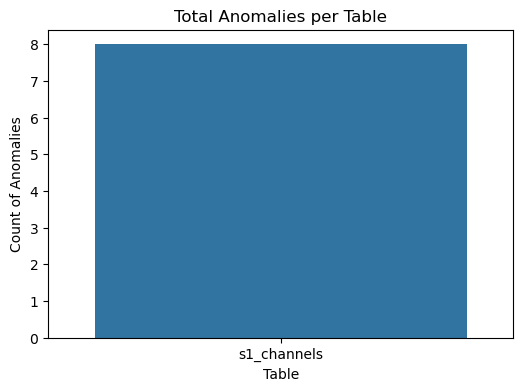

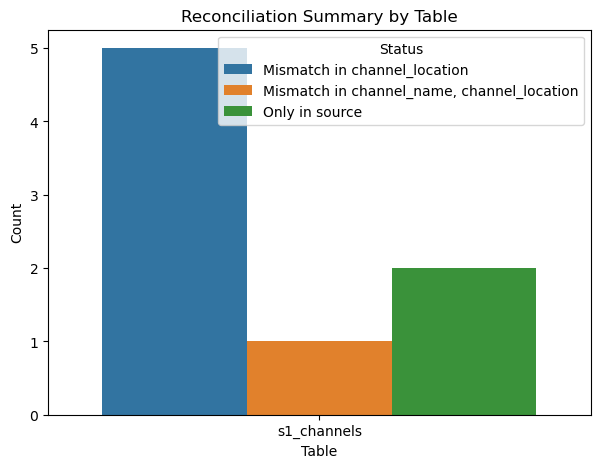

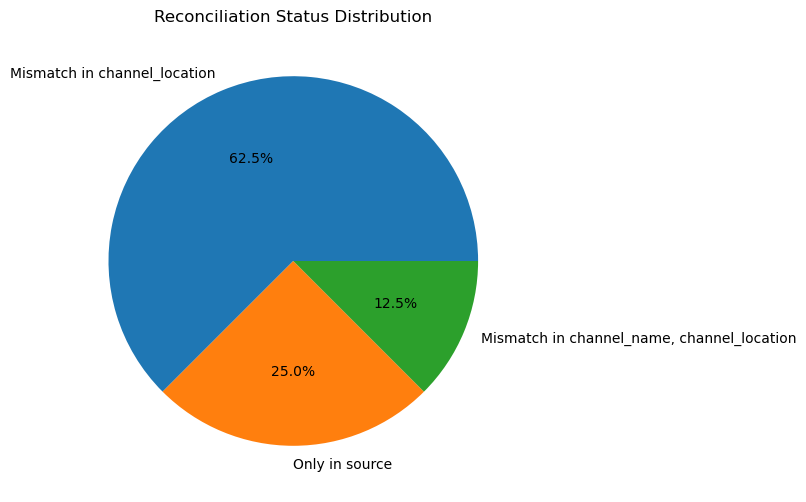